# 3. Analyse exploratoire des données (EDA)

## 3.1 Objectif

L'objectif de cette étape est de comprendre les caractéristiques des données financières utilisées dans le projet avant la phase de création des variables et d'entraînement des modèles d'intelligence artificielle.

Les analyses porteront sur :

- La structure des données
- Les statistiques descriptives
- L'évolution des prix
- La distribution des prix
- La volatilité
- Les corrélations entre variables

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('default')

# 2. Chargement des données

Cette section permet de charger les données prétraitées de l'or (Gold) et de l'argent (Silver).

In [2]:
PROJECT_ROOT = Path.cwd().parent

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

gold = pd.read_csv(PROCESSED_DATA_DIR / "gold_clean.csv")
silver = pd.read_csv(PROCESSED_DATA_DIR / "silver_clean.csv")

print("Gold :", gold.shape)
print("Silver :", silver.shape)

Gold : (11423, 7)
Silver : (11420, 7)


# 3. Aperçu des données

Affichage des cinq premières observations afin de comprendre la structure des données.

In [3]:
print("===== GOLD =====")
display(gold.head())

print("===== SILVER =====")
display(silver.head())

===== GOLD =====


,Datetime,Close,High,Low,Open,Volume,Ticker
0,2024-05-30 04:00:00+00:00,2333.500000,2335.100098,2332.600098,2332.899902,0,GC=F
1,2024-05-30 05:00:00+00:00,2323.699951,2333.699951,2320.800049,2333.000000,617,GC=F
2,2024-05-30 06:00:00+00:00,2331.699951,2331.699951,2322.800049,2323.399902,1913,GC=F
3,2024-05-30 07:00:00+00:00,2355.699951,2356.899902,2331.399902,2331.399902,45741,GC=F
4,2024-05-30 08:00:00+00:00,2356.300049,2357.300049,2330.600098,2355.800049,13770,GC=F


===== SILVER =====


,Datetime,Close,High,Low,Open,Volume,Ticker
0,2024-05-30 04:00:00+00:00,31.815001,31.915001,31.770000,31.780001,0,SI=F
1,2024-05-30 05:00:00+00:00,31.415001,31.865000,31.325001,31.815001,6755,SI=F
2,2024-05-30 06:00:00+00:00,31.610001,31.629999,31.389999,31.415001,3980,SI=F
3,2024-05-30 07:00:00+00:00,31.650000,31.764999,31.584999,31.605000,3067,SI=F
4,2024-05-30 08:00:00+00:00,31.700001,31.740000,31.559999,31.665001,2580,SI=F


# 4. Structure des données

Analyse des colonnes, des types de données et du nombre de valeurs non nulles.

In [4]:
print("===== GOLD =====")
gold.info()

print("\n===== SILVER =====")
silver.info()

===== GOLD =====
<class 'pandas.DataFrame'>
RangeIndex: 11423 entries, 0 to 11422
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Datetime  11423 non-null  str    
 1   Close     11423 non-null  float64
 2   High      11423 non-null  float64
 3   Low       11423 non-null  float64
 4   Open      11423 non-null  float64
 5   Volume    11423 non-null  int64  
 6   Ticker    11423 non-null  str    
dtypes: float64(4), int64(1), str(2)
memory usage: 624.8 KB

===== SILVER =====
<class 'pandas.DataFrame'>
RangeIndex: 11420 entries, 0 to 11419
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Datetime  11420 non-null  str    
 1   Close     11420 non-null  float64
 2   High      11420 non-null  float64
 3   Low       11420 non-null  float64
 4   Open      11420 non-null  float64
 5   Volume    11420 non-null  int64  
 6   Ticker    11420 non-null  str    
dtypes:

# 5. Statistiques descriptives

Calcul des principales statistiques descriptives des données.

In [5]:
print("===== GOLD =====")
display(gold.describe())

print("===== SILVER =====")
display(silver.describe())

===== GOLD =====


,Close,High,Low,Open,Volume
count,11423.000000,11423.000000,11423.000000,11423.000000,11423.000000
mean,3463.904921,3470.431784,3455.453210,3463.649234,8392.545829
std,862.007115,865.694212,858.224531,862.013684,8276.647692
min,2305.800049,2309.199951,2304.199951,2305.800049,0.000000
25%,2679.050049,2682.050049,2674.250000,2678.800049,3457.500000
50%,3333.399902,3338.100098,3327.399902,3333.300049,5966.000000
75%,4222.000000,4228.349854,4203.550049,4222.050049,10430.000000
max,5591.000000,5626.799805,5583.799805,5591.100098,137339.000000


===== SILVER =====


,Close,High,Low,Open,Volume
count,11420.000000,11420.000000,11420.000000,11420.000000,11420.000000
mean,45.594347,45.782326,45.369203,45.590146,3054.531524
std,20.147495,20.332638,19.940924,20.144311,3583.233397
min,26.670000,26.705000,26.504999,26.674999,0.000000
25%,31.365000,31.445000,31.270000,31.370001,943.000000
50%,34.687500,34.767500,34.617500,34.687500,1826.000000
75%,52.714999,52.926250,52.373752,52.692501,3807.000000
max,119.385002,121.785004,118.820000,119.400002,55846.000000


# 6. Analyse du prix de clôture de l'or

Visualisation de l'évolution du prix de clôture du Gold Futures.

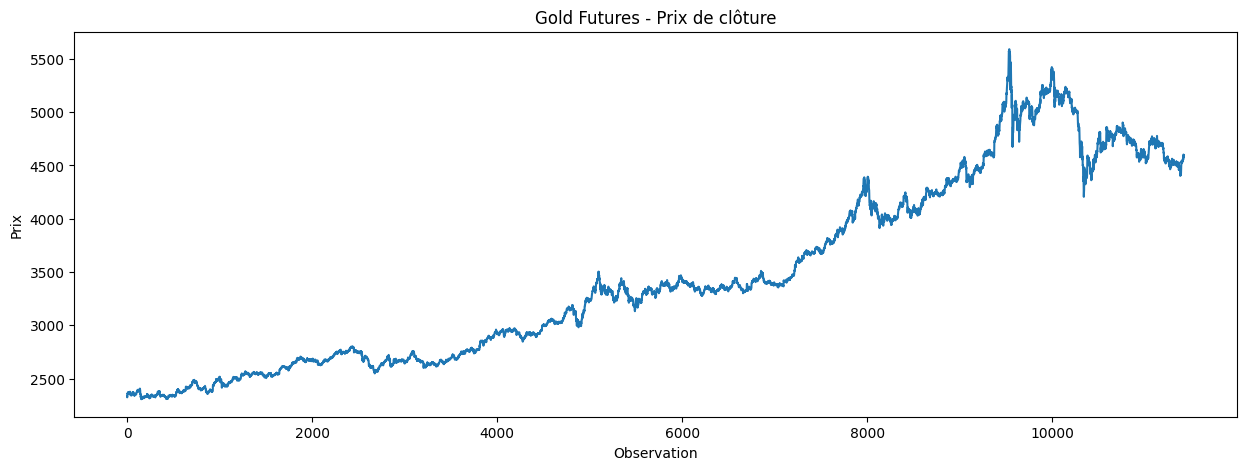

In [6]:
plt.figure(figsize=(15,5))

plt.plot(gold["Close"])

plt.title("Gold Futures - Prix de clôture")
plt.xlabel("Observation")
plt.ylabel("Prix")

plt.show()

# 7. Analyse du prix de clôture de l'argent

Visualisation de l'évolution du prix de clôture du Silver Futures.

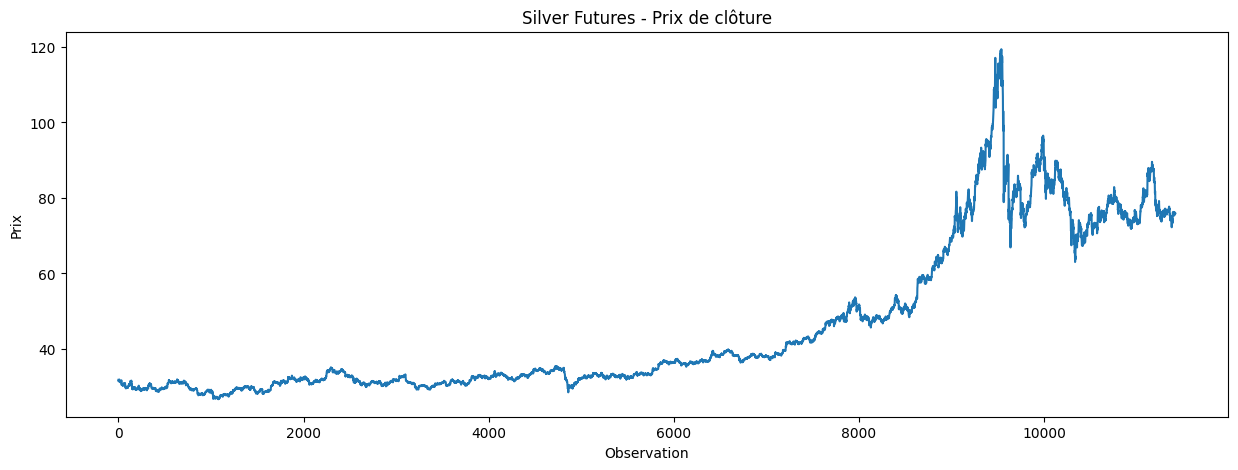

In [14]:
plt.figure(figsize=(15,5))

plt.plot(silver["Close"])

plt.title("Silver Futures - Prix de clôture")
plt.xlabel("Observation")
plt.ylabel("Prix")

plt.show()

# 9. Distribution des prix de l'argent

Analyse de la distribution des prix de clôture du Silver Futures.

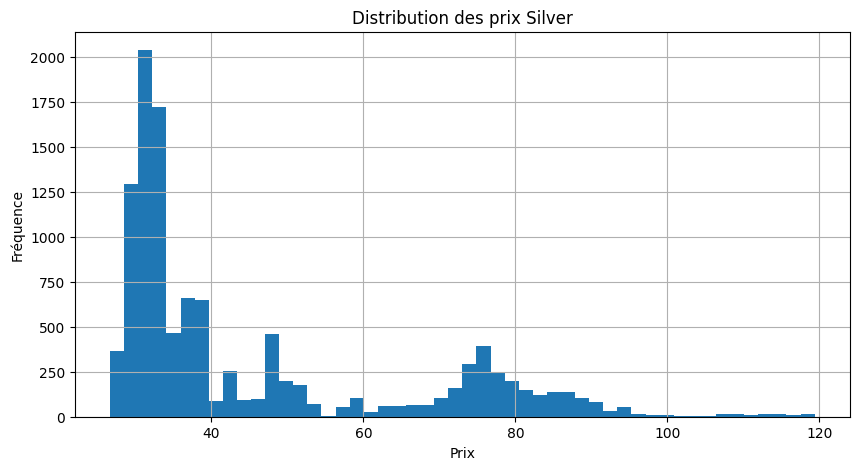

In [7]:
plt.figure(figsize=(10,5))

silver["Close"].hist(bins=50)

plt.title("Distribution des prix Silver")
plt.xlabel("Prix")
plt.ylabel("Fréquence")

plt.show()

# 10. Analyse des rendements

Calcul et analyse des rendements journaliers.

In [8]:
gold["Return"] = gold["Close"].pct_change()

silver["Return"] = silver["Close"].pct_change()

display(gold["Return"].describe())

display(silver["Return"].describe())

count    11422.000000
mean         0.000064
std          0.002969
min         -0.076566
25%         -0.001031
50%          0.000090
75%          0.001276
max          0.029059
Name: Return, dtype: float64

count    11419.000000
mean         0.000097
std          0.006358
min         -0.199239
25%         -0.001926
50%          0.000167
75%          0.002294
max          0.058107
Name: Return, dtype: float64

# 11. Analyse de la volatilité de l'or

Visualisation de la volatilité du Gold Futures à partir des rendements.

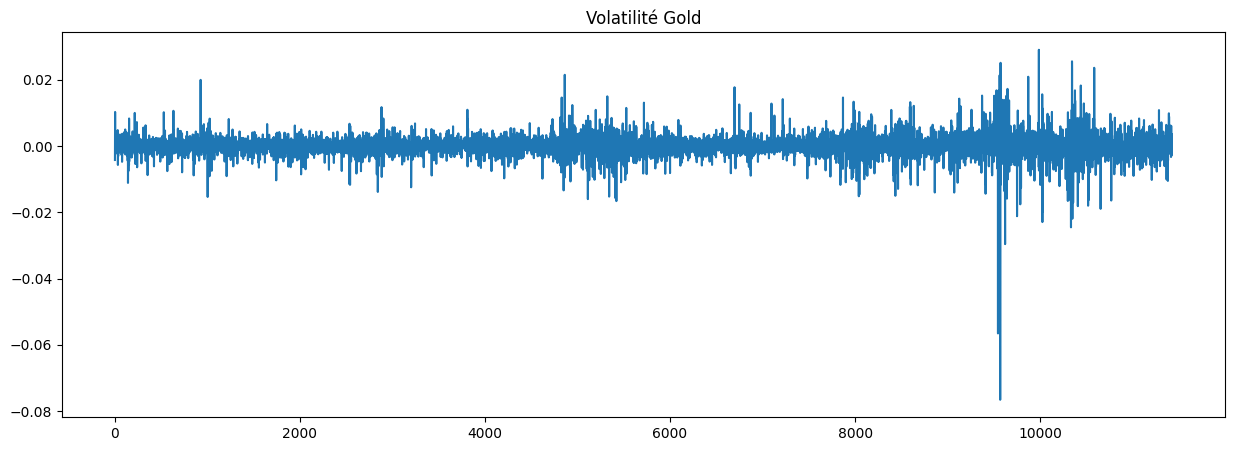

In [9]:
gold["Return"].plot(figsize=(15,5))

plt.title("Volatilité Gold")

plt.show()

# 12. Analyse de la volatilité de l'argent

Visualisation de la volatilité du Silver Futures à partir des rendements.

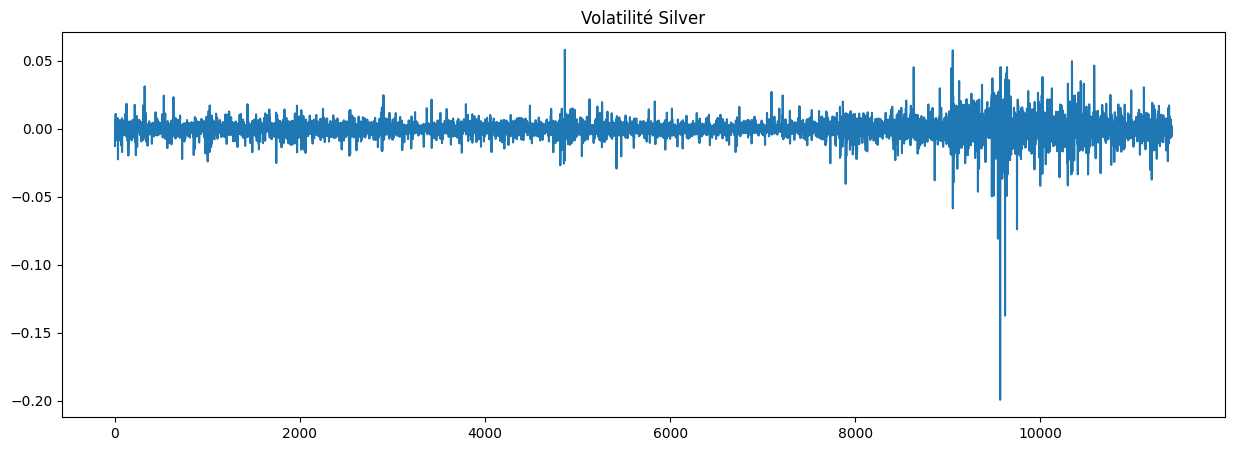

In [10]:
silver["Return"].plot(figsize=(15,5))

plt.title("Volatilité Silver")

plt.show()

# 13. Analyse des corrélations du Gold

Identification des relations entre les variables numériques du Gold Futures.

In [11]:
display(gold.corr(numeric_only=True))

,Close,High,Low,Open,Volume,Return
Close,1.000000,0.999948,0.999934,0.999908,0.038305,0.005228
High,0.999948,1.000000,0.999878,0.999953,0.042123,-0.001297
Low,0.999934,0.999878,1.000000,0.999906,0.034597,0.000734
Open,0.999908,0.999953,0.999906,1.000000,0.039575,-0.007270
Volume,0.038305,0.042123,0.034597,0.039575,1.000000,-0.092143
Return,0.005228,-0.001297,0.000734,-0.007270,-0.092143,1.000000


# 14. Analyse des corrélations du Silver

Identification des relations entre les variables numériques du Silver Futures.

In [13]:
display(silver.corr(numeric_only=True))

,Close,High,Low,Open,Volume,Return
Close,1.000000,0.999868,0.999895,0.999773,0.118045,0.017739
High,0.999868,1.000000,0.999766,0.999908,0.123394,0.007140
Low,0.999895,0.999766,1.000000,0.999809,0.113391,0.011531
Open,0.999773,0.999908,0.999809,1.000000,0.120258,-0.000846
Volume,0.118045,0.123394,0.113391,0.120258,1.000000,-0.086051
Return,0.017739,0.007140,0.011531,-0.000846,-0.086051,1.000000


# 15. Conclusion de l'analyse exploratoire

Cette étape a permis :

- D'analyser la structure des données.
- D'étudier l'évolution des prix du Gold et du Silver.
- D'évaluer la distribution des prix.
- D'analyser les rendements et la volatilité.
- D'identifier les relations entre les variables.

Les résultats obtenus serviront à la création des indicateurs techniques et des variables d'entrée utilisées lors de l'entraînement des modèles d'intelligence artificielle.